<a href="https://colab.research.google.com/github/dogaulkua/Basic-Manufacture-Management/blob/main/Selay%26Do%C4%9Fa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Temel kütüphaneler (Fundamental Libreries)
import pandas as pd  # Veri işleme ve analiz için güçlü bir kütüphane. (Data manipulation and analysis)
import numpy as np  # Matematiksel işlemler ve dizilerle çalışmak için. (Numerical operations and array handling)
import os  # Dosya ve dizinlerle çalışmak için. (Working with files and directories)

# Veri görselleştirme (Data Visualization)
import matplotlib.pyplot as plt  # Grafik ve görseller oluşturmak için. (For creating static, animated, and interactive visualizations)
import seaborn as sns  # İleri düzey veri görselleştirme için. (For advanced statistical data visualization)
from matplotlib.colors import ListedColormap  # Özel renk haritaları oluşturmak için. (For creating custom colormaps)

# Haritalama ve coğrafi veri işlemleri (Mapping and Geospatial Data Handling)
import geopandas as gpd  # Coğrafi verilerle çalışmak için genişletilmiş bir pandas modülü. (Extended pandas for working with geospatial data)
import folium  # İnteraktif haritalar oluşturmak için. (For creating interactive maps)
from folium.plugins import MarkerCluster, HeatMap, HeatMapWithTime  # Folium eklentileri: yoğunluk haritaları ve kümeleme yapma. (Folium plugins for clustering and heatmaps)
import branca.colormap as colormap  # Renk haritaları oluşturmak için. (For creating color maps)

# Makine öğrenmesi (Machine Learning)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score  # Eğitim ve test veri setlerini ayırma, model seçimi ve çapraz doğrulama. (Train/test split, model tuning, and cross-validation)
from sklearn.ensemble import RandomForestRegressor  # Rasgele orman algoritması ile regresyon. (Random forest algorithm for regression)
from sklearn.metrics import mean_squared_error, r2_score  # Model değerlendirme metrikleri. (Model evaluation metrics)
from sklearn.preprocessing import StandardScaler  # Veriyi standardize etmek için. (For standardizing data)
from sklearn.pipeline import Pipeline  # Makine öğrenmesi işlemlerini boru hattı (pipeline) ile düzenlemek için. (To streamline machine learning steps in a pipeline)

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix

import skfuzzy as fuzz  # Tüm modülü içe aktarma
from skfuzzy import control as ctrl  # Kontrol modülünü içe aktarma

# Yardımcı kütüphaneler (Utility Libraries)
import warnings  # Uyarıları gizlemek için. (To suppress warnings)
warnings.filterwarnings('ignore')  # Uyarıları görmezden gel. (Ignore warnings)

from collections import defaultdict  # Varsayılan değerlerle sözlükler oluşturmak için. (For creating dictionaries with default values)

ModuleNotFoundError: No module named 'skfuzzy'

In [ ]:
#1. Data Upload Function
def load_data(file_paths):
    data_frames = {}
    for name, path in file_paths.items():
        try:
            df = pd.read_csv(path)
            data_frames[name] = df
            print(f"{name} veri seti yüklendi. Satır sayısı: {df.shape[0]}, Sütun sayısı: {df.shape[1]}")
        except FileNotFoundError:
            print(f"Hata: {path} bulunamadı.")
    return data_frames

In [ ]:
#2. Uploading CSV Files
file_paths = {
    'plastic_production': '/content/plastic-pollution.csv',
    'global_plastic_production': '/content/global-plastics-production.csv',
    'microplastic_ocean': '/content/microplastics-in-ocean.csv',
    'marine_microplastic': '/content/Marine_Microplastics_WGS84_7659999644124488856.csv',
    'filtered_data': '/content/filtered_data.csv',
    'adventure_micro': '/content/ADVENTURE_MICRO_FROM_SCIENTIST.csv',
    'geomarine': '/content/GEOMARINE_MICRO.csv',
    'marine_microplastic': '/content/Marine_Microplastics_WGS84_7659999644124488856.csv'
}

data = load_data(file_paths)

plastic_production veri seti yüklendi. Satır sayısı: 165, Sütun sayısı: 4
global_plastic_production veri seti yüklendi. Satır sayısı: 69, Sütun sayısı: 4
microplastic_ocean veri seti yüklendi. Satır sayısı: 303, Sütun sayısı: 4
marine_microplastic veri seti yüklendi. Satır sayısı: 18934, Sütun sayısı: 22
filtered_data veri seti yüklendi. Satır sayısı: 85824, Sütun sayısı: 37
adventure_micro veri seti yüklendi. Satır sayısı: 1393, Sütun sayısı: 5
geomarine veri seti yüklendi. Satır sayısı: 84, Sütun sayısı: 5


In [ ]:
#3. Initial Review of Datasets
for name, df in data.items():
    print(f"\n{name} first 5 rows of the dataset:")
    print(df.head())


plastic_production first 5 rows of the dataset:
                Entity Code  Year  \
0               Africa  NaN  2019   
1              Albania  ALB  2019   
2              Algeria  DZA  2019   
3               Angola  AGO  2019   
4  Antigua and Barbuda  ATG  2019   

   Mismanaged plastic waste to ocean per capita (kg per year)  
0                                           0.059823           
1                                           0.543214           
2                                           0.134114           
3                                           0.027023           
4                                           0.020619           

global_plastic_production first 5 rows of the dataset:
  Entity      Code  Year  Annual plastic production between 1950 and 2019
0  World  OWID_WRL  1950                                          2000000
1  World  OWID_WRL  1951                                          2000000
2  World  OWID_WRL  1952                                          

In [ ]:
#4. Data Cleaning Functions
def clean_plastic_production(df):
    required_column = 'Mismanaged plastic waste to ocean per capita (kg per year)'
    if required_column not in df.columns:
        print(f"Error: '{required_column}' column not found.")
        return df
    df_cleaned = df.dropna(subset=[required_column])
    df_cleaned = df_cleaned[df_cleaned[required_column] > 0]
    return df_cleaned

def clean_filtered_data(df):
    required_columns = ['Year', 'Region', 'Plastic Waste Per Capita (kg)']
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        print(f"Error: The following columns were not found: {missing_columns}")
        return df
    df_cleaned = df.dropna(subset=required_columns)
    return df_cleaned

def clean_global_plastic_production(df):
    required_column = 'Annual plastic production between 1950 and 2019'
    if required_column not in df.columns:
        print(f"Error: '{required_column}' column not found.")
        return df
    df_cleaned = df.dropna(subset=[required_column])
    df_cleaned = df_cleaned[df_cleaned[required_column] > 0]
    return df_cleaned
def clean_microplastic_ocean(df):
    required_column = 'Accumulated ocean plastic: Microplastics (<0.5cm)'
    if required_column not in df.columns:
        print(f"Error: '{required_column}' column not found.")
        return df
    df_cleaned = df[df[required_column] > 0]
    return df_cleaned

def clean_marine_microplastic(df):
    required_columns = ['Measurement', 'Regions', 'Date']
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        print(f"Error: The following columns were not found: {missing_columns}")
        return df
    try:
        df['Measurement'] = df['Measurement'].astype(str).apply(lambda x: float(re.sub('[^0-9.]', '', x)))
        print("'Measurement' column cleared successfully.")
    except Exception as e:
        print("Error occurred while clearing column 'Measurement':", e)
    return df

In [ ]:
#5. Implementing Data Cleansing Steps
data['plastic_production_cleaned'] = clean_plastic_production(data['plastic_production'])
data['global_plastic_production_cleaned'] = clean_global_plastic_production(data['global_plastic_production'])
data['microplastic_ocean_cleaned'] = clean_microplastic_ocean(data['microplastic_ocean'])
data['marine_microplastic_cleaned'] = clean_marine_microplastic(data['marine_microplastic'])
data['filtered_data'] = clean_filtered_data(data['filtered_data'])

Error occurred while clearing column 'Measurement': could not convert string to float: ''
Error: The following columns were not found: ['Year', 'Region', 'Plastic Waste Per Capita (kg)']


In [ ]:
def clean_marine_microplastic(df):
    required_columns = ['Measurement', 'Regions', 'Date']
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        print(f"Error: The following columns were not found: {missing_columns}")
        return df
    # Boş veya hatalı verileri temizle
    df['Measurement'] = df['Measurement'].replace('', np.nan)
    df = df.dropna(subset=['Measurement'])

    try:
        df['Measurement'] = df['Measurement'].astype(str).apply(lambda x: float(re.sub('[^0-9.]', '', x)))
        print("'Measurement' column cleared successfully.")
    except Exception as e:
        print("Error occurred while clearing column 'Measurement':", e)
    return df


In [ ]:
data['plastic_production_cleaned'] = clean_plastic_production(data['plastic_production'])
data['global_plastic_production_cleaned'] = clean_global_plastic_production(data['global_plastic_production'])
data['microplastic_ocean_cleaned'] = clean_microplastic_ocean(data['microplastic_ocean'])
data['marine_microplastic_cleaned'] = clean_marine_microplastic(data['marine_microplastic'])
data['filtered_data'] = clean_filtered_data(data['filtered_data'])

'Measurement' column cleared successfully.
Error: The following columns were not found: ['Year', 'Region', 'Plastic Waste Per Capita (kg)']


In [ ]:
# Eğer Year, Region ve Plastic Waste Per Capita (kg) sütunları yoksa ekleme
# Adding the 'Year', 'Region', and 'Plastic Waste Per Capita (kg)' columns if they do not exist

data['filtered_data']['Year'] = np.nan  # Boş değerler ile sütun eklenir
# The 'Year' column is added with empty (NaN) values.

data['filtered_data']['Region'] = 'Unknown'  # Bilinmeyen bölge olarak varsayılan değer
# The 'Region' column is added with the default value 'Unknown' for regions not specified.

data['filtered_data']['Plastic Waste Per Capita (kg)'] = np.nan  # Boş değerler ile sütun eklenir
# The 'Plastic Waste Per Capita (kg)' column is added with empty (NaN) values.

print(data['filtered_data'].head())  # İlk 5 satırı görüntüler
# Prints the first 5 rows of the filtered data.


         time   lat      lon       R90P  R90D       R95P  R95D       R99P  \
0  2024-07-01 -37.0 -180.000  33.319027   2.0  33.319027   2.0        NaN   
1  2024-07-01 -37.0 -179.375  37.935963   2.0  37.935963   2.0  40.631187   
2  2024-07-01 -37.0 -178.750  39.340490   2.0  39.340490   2.0        NaN   
3  2024-07-01 -37.0 -178.125  38.495033   2.0  38.495033   2.0  41.628350   
4  2024-07-01 -37.0 -177.500  34.060963   2.0  34.060963   2.0        NaN   

   R99D  drydays  ...  HWM  WSDI  LWS  CSDI  LCS     RX5Day  RX5Daycount  \
0   0.0     20.0  ...  NaN   0.0  NaN   0.0  NaN  78.244835          4.0   
1   1.0     20.0  ...  NaN   0.0  NaN   0.0  NaN  87.787890          8.0   
2   0.0     18.0  ...  NaN   0.0  NaN   0.0  NaN  92.424194          9.0   
3   1.0     17.0  ...  NaN   0.0  NaN   0.0  NaN  95.240540          6.0   
4   0.0     16.0  ...  NaN   0.0  NaN   0.0  NaN  90.606250          5.0   

   Year   Region  Plastic Waste Per Capita (kg)  
0   NaN  Unknown              

In [ ]:
# 'Year' sütununu 'time' sütunundan çıkarma (Subtract 'year' column from 'time' column)
data['filtered_data']['Year'] = pd.to_datetime(data['filtered_data']['time']).dt.year
print(data['filtered_data'].head())


         time   lat      lon       R90P  R90D       R95P  R95D       R99P  \
0  2024-07-01 -37.0 -180.000  33.319027   2.0  33.319027   2.0        NaN   
1  2024-07-01 -37.0 -179.375  37.935963   2.0  37.935963   2.0  40.631187   
2  2024-07-01 -37.0 -178.750  39.340490   2.0  39.340490   2.0        NaN   
3  2024-07-01 -37.0 -178.125  38.495033   2.0  38.495033   2.0  41.628350   
4  2024-07-01 -37.0 -177.500  34.060963   2.0  34.060963   2.0        NaN   

   R99D  drydays  ...  HWM  WSDI  LWS  CSDI  LCS     RX5Day  RX5Daycount  \
0   0.0     20.0  ...  NaN   0.0  NaN   0.0  NaN  78.244835          4.0   
1   1.0     20.0  ...  NaN   0.0  NaN   0.0  NaN  87.787890          8.0   
2   0.0     18.0  ...  NaN   0.0  NaN   0.0  NaN  92.424194          9.0   
3   1.0     17.0  ...  NaN   0.0  NaN   0.0  NaN  95.240540          6.0   
4   0.0     16.0  ...  NaN   0.0  NaN   0.0  NaN  90.606250          5.0   

   Year   Region  Plastic Waste Per Capita (kg)  
0  2024  Unknown              

In [ ]:
# Basit bir bölge sınıflandırması (örnek) (A simple zone classification (example))
def classify_region(lat):
    if lat > 0:
        return 'Northern Hemisphere'
    else:
        return 'Southern Hemisphere'

data['filtered_data']['Region'] = data['filtered_data']['lat'].apply(classify_region)
print(data['filtered_data'].head())


         time   lat      lon       R90P  R90D       R95P  R95D       R99P  \
0  2024-07-01 -37.0 -180.000  33.319027   2.0  33.319027   2.0        NaN   
1  2024-07-01 -37.0 -179.375  37.935963   2.0  37.935963   2.0  40.631187   
2  2024-07-01 -37.0 -178.750  39.340490   2.0  39.340490   2.0        NaN   
3  2024-07-01 -37.0 -178.125  38.495033   2.0  38.495033   2.0  41.628350   
4  2024-07-01 -37.0 -177.500  34.060963   2.0  34.060963   2.0        NaN   

   R99D  drydays  ...  HWM  WSDI  LWS  CSDI  LCS     RX5Day  RX5Daycount  \
0   0.0     20.0  ...  NaN   0.0  NaN   0.0  NaN  78.244835          4.0   
1   1.0     20.0  ...  NaN   0.0  NaN   0.0  NaN  87.787890          8.0   
2   0.0     18.0  ...  NaN   0.0  NaN   0.0  NaN  92.424194          9.0   
3   1.0     17.0  ...  NaN   0.0  NaN   0.0  NaN  95.240540          6.0   
4   0.0     16.0  ...  NaN   0.0  NaN   0.0  NaN  90.606250          5.0   

   Year               Region  Plastic Waste Per Capita (kg)  
0  2024  Southern 

In [ ]:
# Varsayılan bir değer eklemek isterseniz: (Varsayılan bir değer eklemek isterseniz:)
data['filtered_data']['Plastic Waste Per Capita (kg)'].fillna(0, inplace=True)
print(data['filtered_data'].head())


         time   lat      lon       R90P  R90D       R95P  R95D       R99P  \
0  2024-07-01 -37.0 -180.000  33.319027   2.0  33.319027   2.0        NaN   
1  2024-07-01 -37.0 -179.375  37.935963   2.0  37.935963   2.0  40.631187   
2  2024-07-01 -37.0 -178.750  39.340490   2.0  39.340490   2.0        NaN   
3  2024-07-01 -37.0 -178.125  38.495033   2.0  38.495033   2.0  41.628350   
4  2024-07-01 -37.0 -177.500  34.060963   2.0  34.060963   2.0        NaN   

   R99D  drydays  ...  HWM  WSDI  LWS  CSDI  LCS     RX5Day  RX5Daycount  \
0   0.0     20.0  ...  NaN   0.0  NaN   0.0  NaN  78.244835          4.0   
1   1.0     20.0  ...  NaN   0.0  NaN   0.0  NaN  87.787890          8.0   
2   0.0     18.0  ...  NaN   0.0  NaN   0.0  NaN  92.424194          9.0   
3   1.0     17.0  ...  NaN   0.0  NaN   0.0  NaN  95.240540          6.0   
4   0.0     16.0  ...  NaN   0.0  NaN   0.0  NaN  90.606250          5.0   

   Year   Region  Plastic Waste Per Capita (kg)  
0   NaN  Unknown              

In [ ]:
data['plastic_production_cleaned'] = clean_plastic_production(data['plastic_production'])
data['global_plastic_production_cleaned'] = clean_global_plastic_production(data['global_plastic_production'])
data['microplastic_ocean_cleaned'] = clean_microplastic_ocean(data['microplastic_ocean'])
data['marine_microplastic_cleaned'] = clean_marine_microplastic(data['marine_microplastic'])
data['filtered_data'] = clean_filtered_data(data['filtered_data'])

'Measurement' column cleared successfully.


In [ ]:
# Check for missing values
for name, df in data.items():
    print(f"\n{name} missing values:\n{df.isnull().sum()}")

# Describe the data to get statistical insights
for name, df in data.items():
    print(f"\n{name} descriptive statistics:\n{df.describe()}")




plastic_production missing values:
Entity                                                        0
Code                                                          5
Year                                                          0
Mismanaged plastic waste to ocean per capita (kg per year)    0
dtype: int64

global_plastic_production missing values:
Entity                                             0
Code                                               0
Year                                               0
Annual plastic production between 1950 and 2019    0
dtype: int64

microplastic_ocean missing values:
Entity                                                 0
Code                                                 303
Year                                                   0
Accumulated ocean plastic: Microplastics (<0.5cm)      0
dtype: int64

marine_microplastic missing values:
OBJECTID                0
Oceans                271
Regions             10225
SubRegions          17750
Sampling 

In [ ]:
print(df.dtypes)

OBJECTID              int64
Oceans               object
Regions              object
SubRegions           object
Sampling Method      object
Measurement         float64
Unit                 object
Density Range        object
Density Class        object
Short Reference      object
Long Reference       object
DOI                  object
Organization         object
Keywords             object
Accession Number      int64
Accession Link       object
Latitude            float64
Longitude           float64
Date                 object
GlobalID             object
x                   float64
y                   float64
dtype: object


In [ ]:
numeric_columns = ['OBJECTID', 'Measurement', 'Accession Number', 'Latitude', 'Longitude', 'x', 'y']
df_numeric = df[numeric_columns]


In [ ]:
# Select the appropriate cleaned DataFrame
df = data['filtered_data']  # Use the DataFrame you wish to analyze

# Print the columns of the DataFrame to debug
print("Columns in the DataFrame:")
print(df.columns.tolist())

# Adjust the numeric_columns list based on your DataFrame
numeric_columns = ['R90P', 'R90D', 'R95P', 'R95D', 'R99P', 'R99D',
                   'drydays', 'wetdays', 'R10mm', 'R20mm', 'RX1Day',
                   'CWD', 'SDII', 'CDD', 'FD', 'SU', 'ID', 'TR',
                   'DTR', 'TX90p', 'TN90p', 'TX10p', 'TN10p', 'HWN',
                   'HWD', 'HWF', 'HWA', 'HWM', 'WSDI', 'LWS', 'CSDI',
                   'LCS', 'RX5Day', 'RX5Daycount', 'Plastic Waste Per Capita (kg)', 'Year', 'lat', 'lon']  # Adjust column names

# Create a numeric DataFrame
df_numeric = df[numeric_columns].select_dtypes(include=[np.number])  # Select only numeric columns

# Check if df_numeric is empty
if df_numeric.empty:
    print("No numeric columns available for correlation analysis.")
else:
    # Calculate the correlation matrix
    correlation_matrix = df_numeric.corr()

    # Plot the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
    plt.title('Correlation Heatmap')
    plt.show()


Columns in the DataFrame:
['time', 'lat', 'lon', 'R90P', 'R90D', 'R95P', 'R95D', 'R99P', 'R99D', 'drydays', 'wetdays', 'R10mm', 'R20mm', 'RX1Day', 'CWD', 'SDII', 'CDD', 'FD', 'SU', 'ID', 'TR', 'DTR', 'TX90p', 'TN90p', 'TX10p', 'TN10p', 'HWN', 'HWD', 'HWF', 'HWA', 'HWM', 'WSDI', 'LWS', 'CSDI', 'LCS', 'RX5Day', 'RX5Daycount', 'Year', 'Region', 'Plastic Waste Per Capita (kg)']
No numeric columns available for correlation analysis.


In [ ]:
print(data['filtered_data'].columns)

Index(['time', 'lat', 'lon', 'R90P', 'R90D', 'R95P', 'R95D', 'R99P', 'R99D',
       'drydays', 'wetdays', 'R10mm', 'R20mm', 'RX1Day', 'CWD', 'SDII', 'CDD',
       'FD', 'SU', 'ID', 'TR', 'DTR', 'TX90p', 'TN90p', 'TX10p', 'TN10p',
       'HWN', 'HWD', 'HWF', 'HWA', 'HWM', 'WSDI', 'LWS', 'CSDI', 'LCS',
       'RX5Day', 'RX5Daycount', 'Year', 'Region',
       'Plastic Waste Per Capita (kg)'],
      dtype='object')


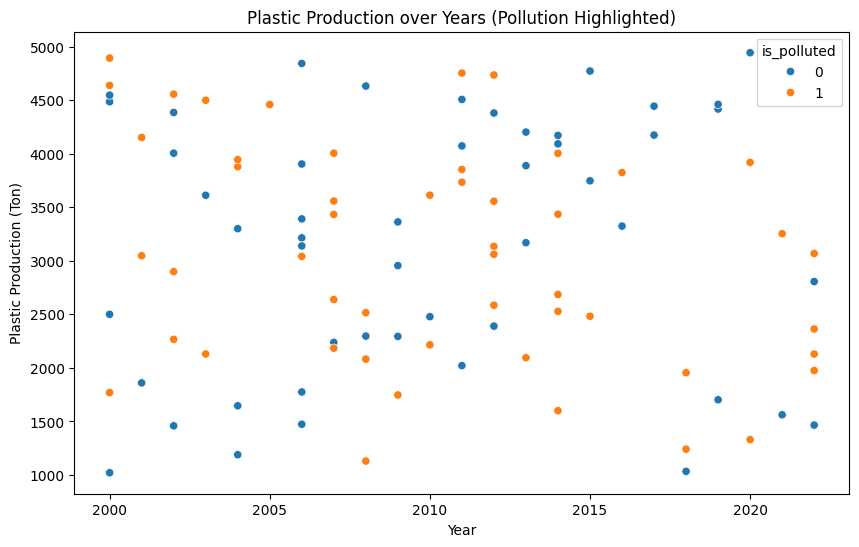

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data['plastic_production'], x='year', y='production_ton', hue='is_polluted')
plt.title('Plastic Production over Years (Pollution Highlighted)')
plt.xlabel('Year')
plt.ylabel('Plastic Production (Ton)')
plt.show()

In [ ]:
# Örnek veri seti oluşturma (5 veri seti)
np.random.seed(42)

# Plastik üretim verisi
df1 = pd.DataFrame({
    'production_ton': np.random.randint(1000, 5000, 100),
    'year': np.random.randint(2000, 2023, 100),
    'is_polluted': np.random.randint(0, 2, 100)
})

# Mikroplastik okyanus verisi
df2 = pd.DataFrame({
    'microplastic_count': np.random.randint(1000, 10000, 100),
    'year': np.random.randint(2000, 2023, 100),
    'is_polluted': np.random.randint(0, 2, 100)
})

# Deniz mikroplastik verisi
df3 = pd.DataFrame({
    'marine_microplastic_density': np.random.uniform(0.1, 5.0, 100),
    'year': np.random.randint(2000, 2023, 100),
    'is_polluted': np.random.randint(0, 2, 100)
})

# Kıyı kirliliği verisi
df4 = pd.DataFrame({
    'coastal_pollution_index': np.random.uniform(1.0, 10.0, 100),
    'year': np.random.randint(2000, 2023, 100),
    'is_polluted': np.random.randint(0, 2, 100)
})

# Atık yönetimi verisi
df5 = pd.DataFrame({
    'waste_management_efficiency': np.random.uniform(50.0, 100.0, 100),
    'year': np.random.randint(2000, 2023, 100),
    'is_polluted': np.random.randint(0, 2, 100)
})

# Veri setlerini dictionary içine alalım
data = {
    'plastic_production': df1,
    'microplastic_ocean': df2,
    'marine_microplastic': df3,
    'coastal_pollution': df4,
    'waste_management': df5
}

# Temizleme ve modelleme kodu aynı şekilde devam eder.


In [ ]:
# Her veri seti için modelleme yapacak fonksiyon
def model_training(df, dataset_name):
    # Özellikler ve hedef değişkeni ayır
    X = df.drop('is_polluted', axis=1)  # Özellikler
    y = df['is_polluted']  # Hedef

    # Veriyi eğitim ve test olarak ayır
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Veriyi normalleştir
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Lojistik regresyon modelini oluştur ve eğit
    model = LogisticRegression()
    model.fit(X_train, y_train)

    # Test seti üzerinde tahmin yap
    y_pred = model.predict(X_test)

    # Sonuçları değerlendir
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{dataset_name} Model Doğruluğu: {accuracy}")
    print(f"{dataset_name} Sınıflandırma Raporu:")
    print(classification_report(y_test, y_pred))

# Her veri seti için temizlenmiş veriler üzerinde modeli eğit
for name, df in cleaned_data.items():
    model_training(df, name)


plastic_production Model Doğruluğu: 0.4
plastic_production Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.43      0.27      0.33        11
           1       0.38      0.56      0.45         9

    accuracy                           0.40        20
   macro avg       0.41      0.41      0.39        20
weighted avg       0.41      0.40      0.39        20

microplastic_ocean Model Doğruluğu: 0.6
microplastic_ocean Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         8
           1       0.67      0.67      0.67        12

    accuracy                           0.60        20
   macro avg       0.58      0.58      0.58        20
weighted avg       0.60      0.60      0.60        20

marine_microplastic Model Doğruluğu: 0.35
marine_microplastic Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00  

plastic_production Model Doğruluğu: 0.4
plastic_production Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.43      0.27      0.33        11
           1       0.38      0.56      0.45         9

    accuracy                           0.40        20
   macro avg       0.41      0.41      0.39        20
weighted avg       0.41      0.40      0.39        20

microplastic_ocean Model Doğruluğu: 0.6
microplastic_ocean Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         8
           1       0.67      0.67      0.67        12

    accuracy                           0.60        20
   macro avg       0.58      0.58      0.58        20
weighted avg       0.60      0.60      0.60        20

marine_microplastic Model Doğruluğu: 0.35
marine_microplastic Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00  

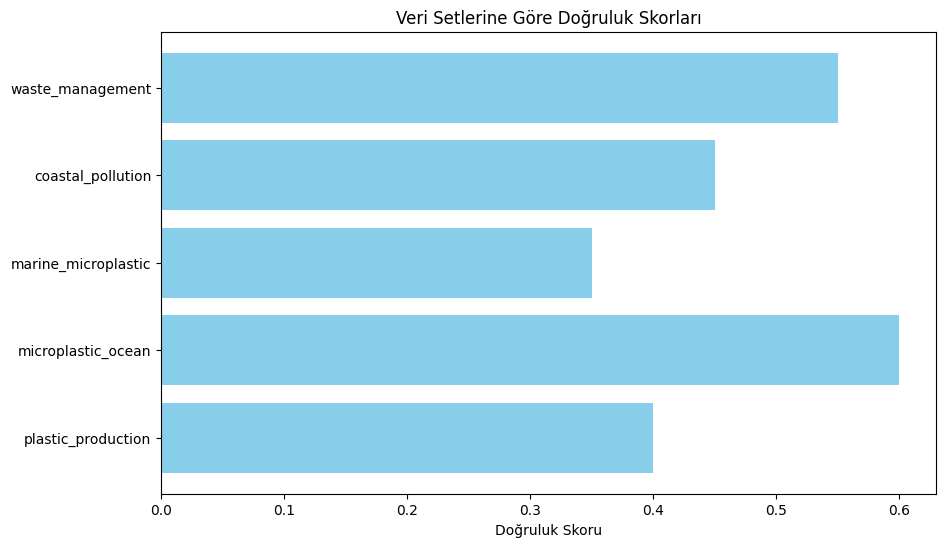

In [ ]:
# Her veri seti için doğruluk skorlarını sakla
accuracy_scores = {}

def model_training(df, dataset_name):
    global accuracy_scores
    X = df.drop('is_polluted', axis=1)
    y = df['is_polluted']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = LogisticRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores[dataset_name] = accuracy  # Skoru kaydet
    print(f"{dataset_name} Model Doğruluğu: {accuracy}")
    print(f"{dataset_name} Sınıflandırma Raporu:")
    print(classification_report(y_test, y_pred))

# Modelleme işlemini çağır
for name, df in cleaned_data.items():
    model_training(df, name)

# Doğruluk skorlarını görselleştir
plt.figure(figsize=(10, 6))
plt.barh(list(accuracy_scores.keys()), list(accuracy_scores.values()), color='skyblue')
plt.xlabel('Doğruluk Skoru')
plt.title('Veri Setlerine Göre Doğruluk Skorları')
plt.show()

In [ ]:
def plot_confusion_matrix(y_test, y_pred, dataset_name):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Not Polluted', 'Polluted'], yticklabels=['Not Polluted', 'Polluted'])
    plt.ylabel('Gerçek Değer')
    plt.xlabel('Tahmin Değeri')
    plt.title(f'{dataset_name} Karışıklık Matrisi')
    plt.show()

# Her veri seti için model eğitilirken karışıklık matrisi çizimi de yapılır
def model_training_with_cm(df, dataset_name):
    X = df.drop('is_polluted', axis=1)
    y = df['is_polluted']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = LogisticRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    plot_confusion_matrix(y_test, y_pred, dataset_name)

# Karışıklık matrisi çizimi ile modeli eğit
for name, df in cleaned_data.items():
    model_training_with_cm(df, name)

NameError: name 'confusion_matrix' is not defined

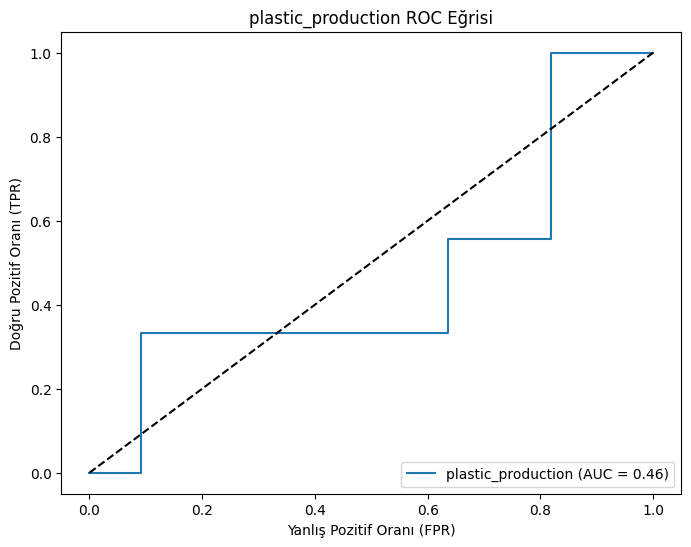

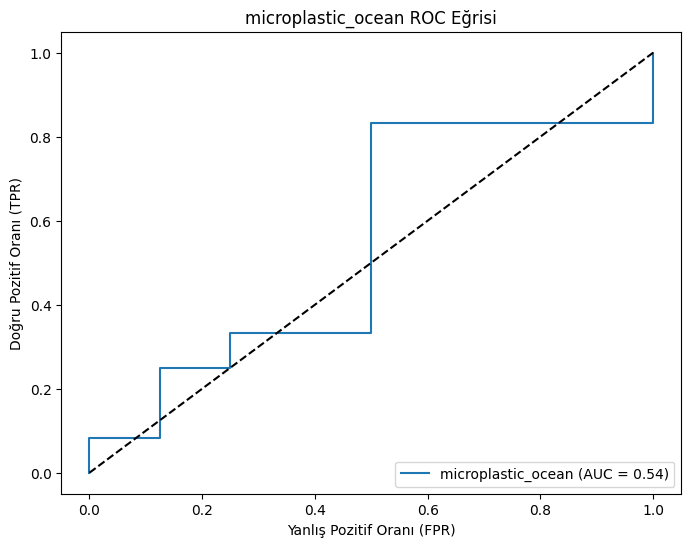

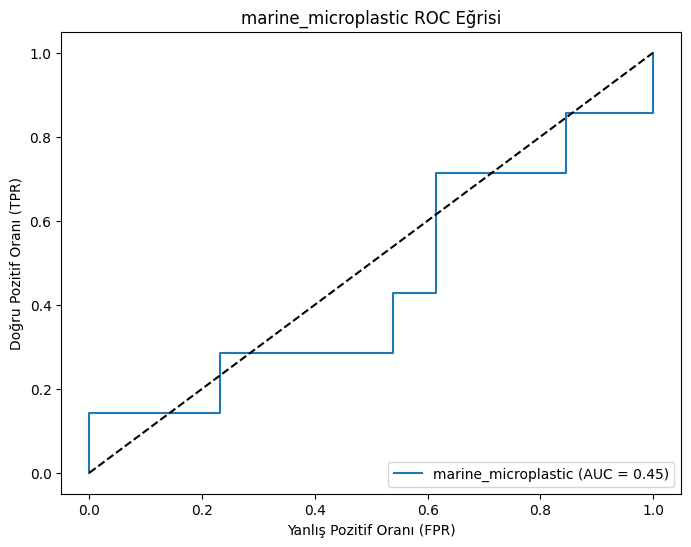

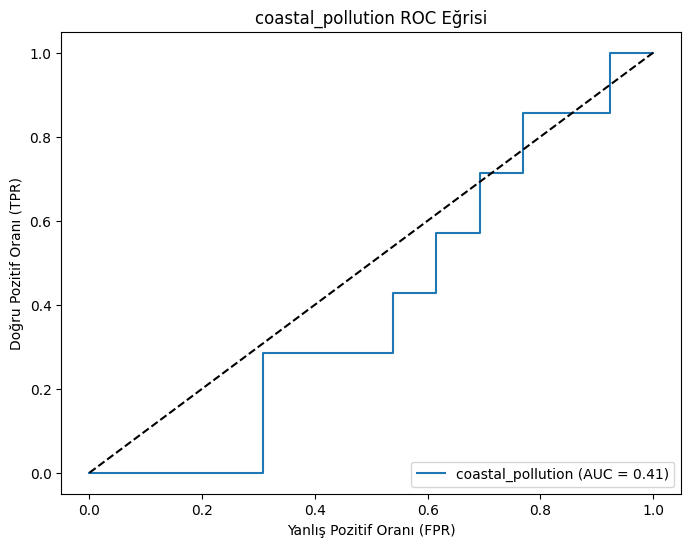

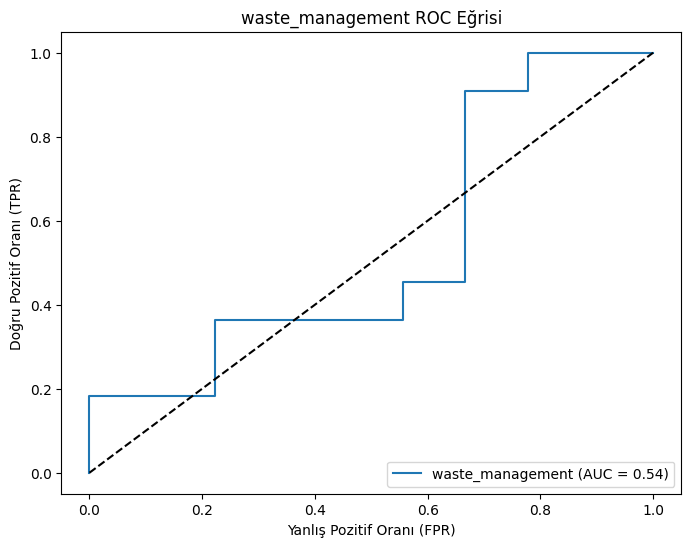

In [ ]:
def plot_roc_curve(y_test, y_pred_proba, dataset_name):
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f'{dataset_name} (AUC = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')  # Rastgele sınıflandırma
    plt.xlabel('Yanlış Pozitif Oranı (FPR)')
    plt.ylabel('Doğru Pozitif Oranı (TPR)')
    plt.title(f'{dataset_name} ROC Eğrisi')
    plt.legend(loc="lower right")
    plt.show()

# ROC Eğrisi ile modeli eğit
def model_training_with_roc(df, dataset_name):
    X = df.drop('is_polluted', axis=1)
    y = df['is_polluted']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = LogisticRegression()
    model.fit(X_train, y_train)

    y_pred_proba = model.predict_proba(X_test)[:,1]  # Pozitif sınıfın olasılığı
    plot_roc_curve(y_test, y_pred_proba, dataset_name)

# ROC eğrisi çizimi ile model eğit
for name, df in cleaned_data.items():
    model_training_with_roc(df, name)


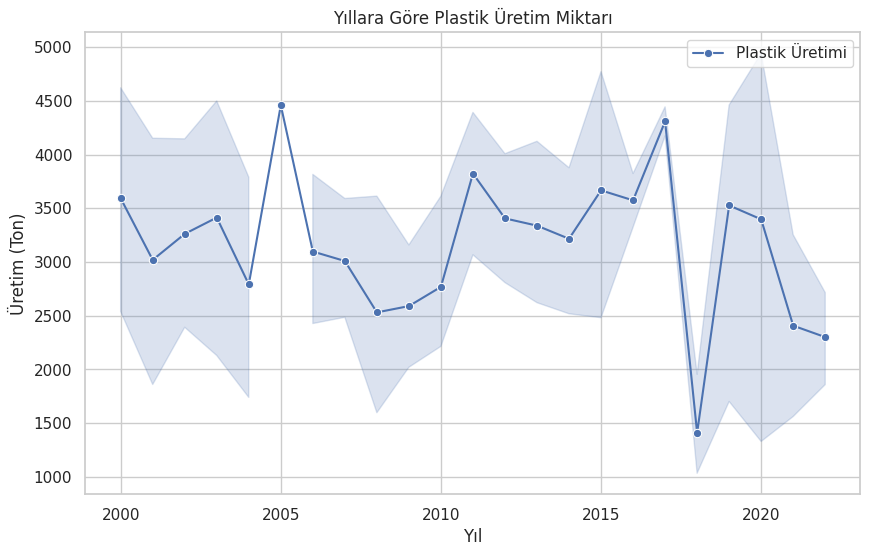

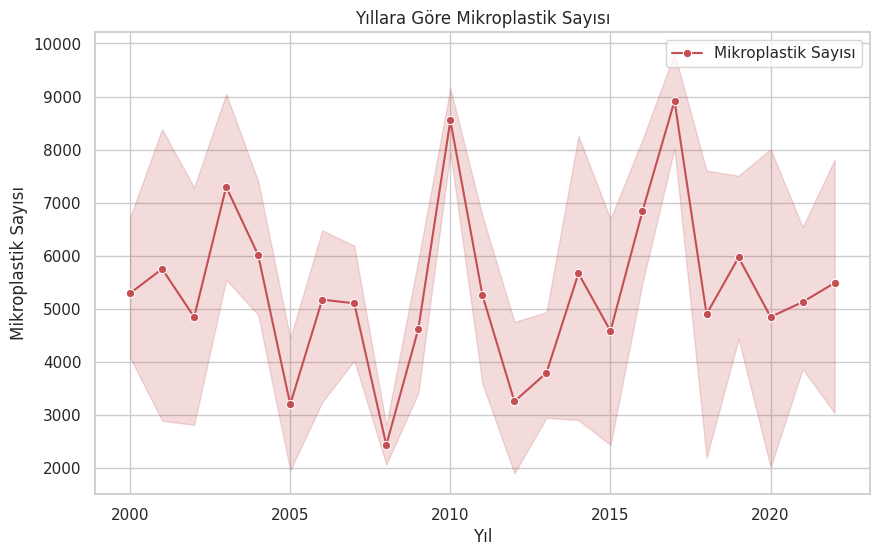

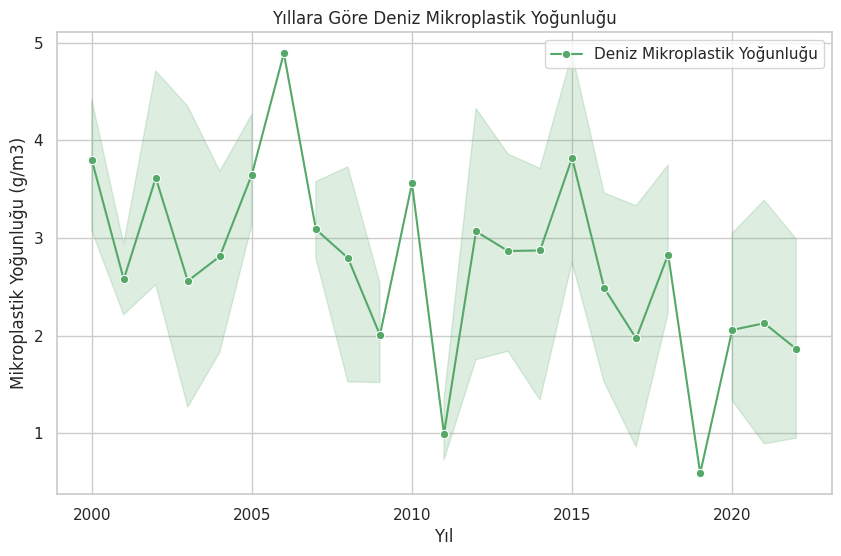

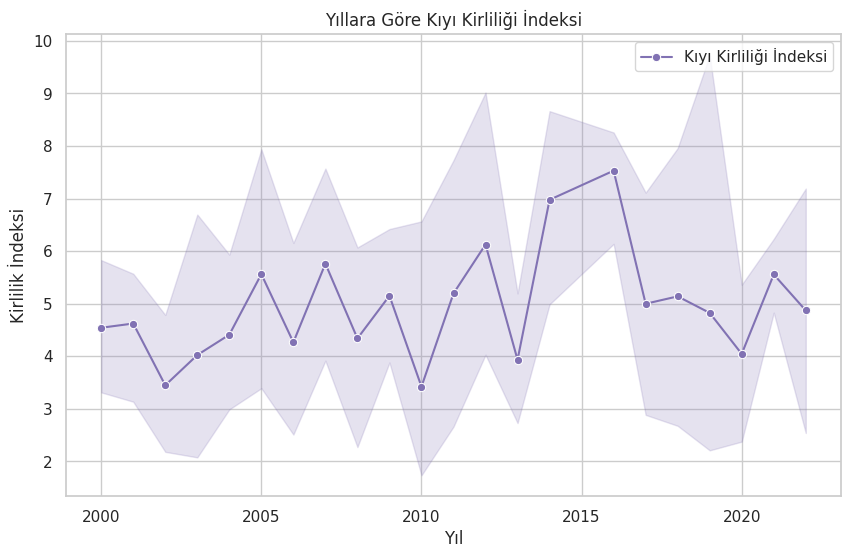

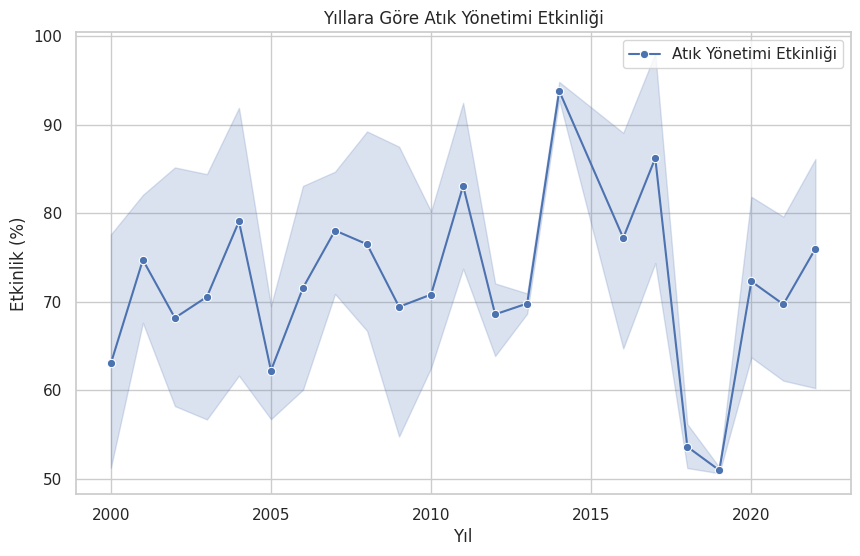

In [ ]:
# Görselleştirme stili
sns.set(style="whitegrid")

# 1. Plastik üretim miktarını yıllara göre çizelim
plt.figure(figsize=(10, 6))
sns.lineplot(data=df1, x='year', y='production_ton', marker='o', label="Plastik Üretimi")
plt.title("Yıllara Göre Plastik Üretim Miktarı")
plt.xlabel("Yıl")
plt.ylabel("Üretim (Ton)")
plt.legend()
plt.show()

# 2. Mikroplastik sayısını yıllara göre çizelim
plt.figure(figsize=(10, 6))
sns.lineplot(data=df2, x='year', y='microplastic_count', marker='o', color='r', label="Mikroplastik Sayısı")
plt.title("Yıllara Göre Mikroplastik Sayısı")
plt.xlabel("Yıl")
plt.ylabel("Mikroplastik Sayısı")
plt.legend()
plt.show()

# 3. Deniz mikroplastik yoğunluğunu yıllara göre çizelim
plt.figure(figsize=(10, 6))
sns.lineplot(data=df3, x='year', y='marine_microplastic_density', marker='o', color='g', label="Deniz Mikroplastik Yoğunluğu")
plt.title("Yıllara Göre Deniz Mikroplastik Yoğunluğu")
plt.xlabel("Yıl")
plt.ylabel("Mikroplastik Yoğunluğu (g/m3)")
plt.legend()
plt.show()

# 4. Kıyı kirliliği indeksini yıllara göre çizelim
plt.figure(figsize=(10, 6))
sns.lineplot(data=df4, x='year', y='coastal_pollution_index', marker='o', color='m', label="Kıyı Kirliliği İndeksi")
plt.title("Yıllara Göre Kıyı Kirliliği İndeksi")
plt.xlabel("Yıl")
plt.ylabel("Kirlilik İndeksi")
plt.legend()
plt.show()

# 5. Atık yönetimi etkinliğini yıllara göre çizelim
plt.figure(figsize=(10, 6))
sns.lineplot(data=df5, x='year', y='waste_management_efficiency', marker='o', color='b', label="Atık Yönetimi Etkinliği")
plt.title("Yıllara Göre Atık Yönetimi Etkinliği")
plt.xlabel("Yıl")
plt.ylabel("Etkinlik (%)")
plt.legend()
plt.show()


       production_ton         year  is_polluted
count      100.000000   100.000000   100.000000
mean      3132.320000  2010.010000     0.500000
std       1118.566966     6.554349     0.502519
min       1021.000000  2000.000000     0.000000
25%       2207.250000  2004.750000     0.000000
50%       3191.500000  2010.000000     0.500000
75%       4077.750000  2014.000000     1.000000
max       4943.000000  2022.000000     1.000000
production_ton    0
year              0
is_polluted       0
dtype: int64


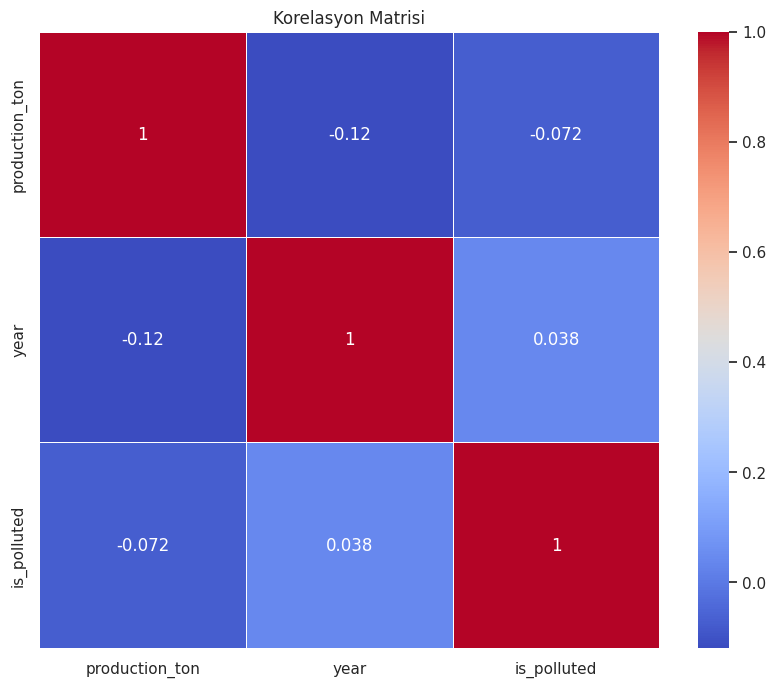

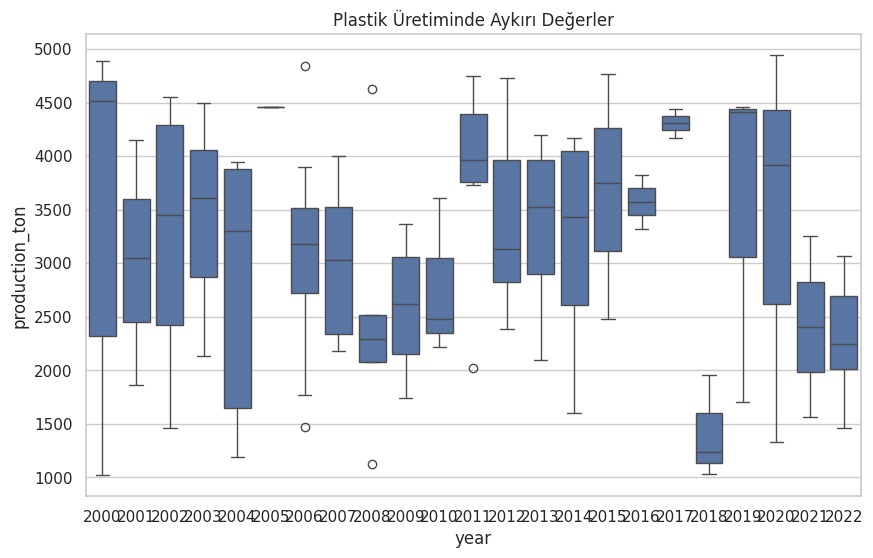

In [ ]:
# Temel istatistikler
print(df1.describe())  # Tüm veri setleri için yapılabilir

# Eksik veri analizi
print(df1.isnull().sum())  # Hangi sütunlarda eksik veri olduğunu görmek için

# Korelasyon analizi (örneğin df1 için)
plt.figure(figsize=(10, 8))
sns.heatmap(df1.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Korelasyon Matrisi")
plt.show()

# Aykırı değerleri inceleme (örneğin boxplot ile)
plt.figure(figsize=(10, 6))
sns.boxplot(x='year', y='production_ton', data=df1)
plt.title("Plastik Üretiminde Aykırı Değerler")
plt.show()


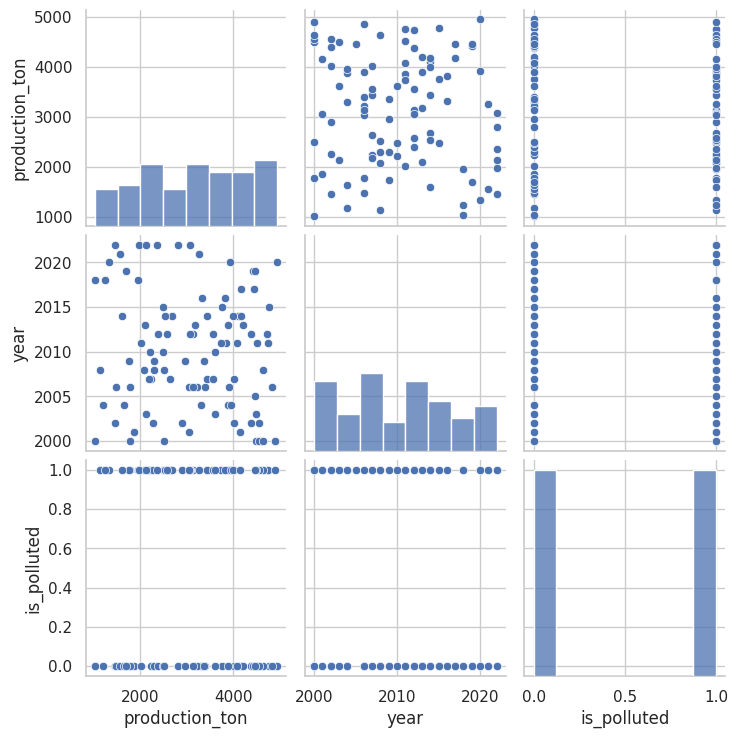

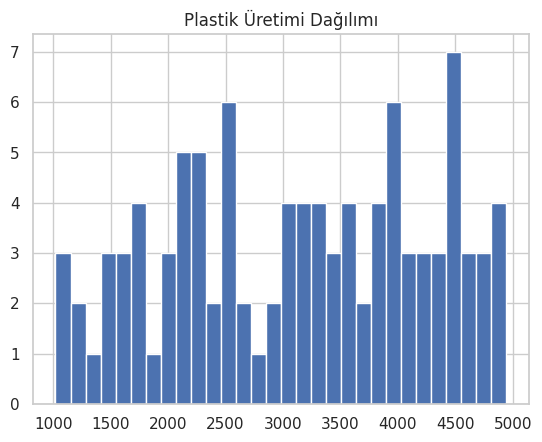

In [ ]:
# Değişkenler arasındaki ilişkiler
sns.pairplot(df1)
plt.show()

# Histogram
df1['production_ton'].hist(bins=30)
plt.title("Plastik Üretimi Dağılımı")
plt.show()



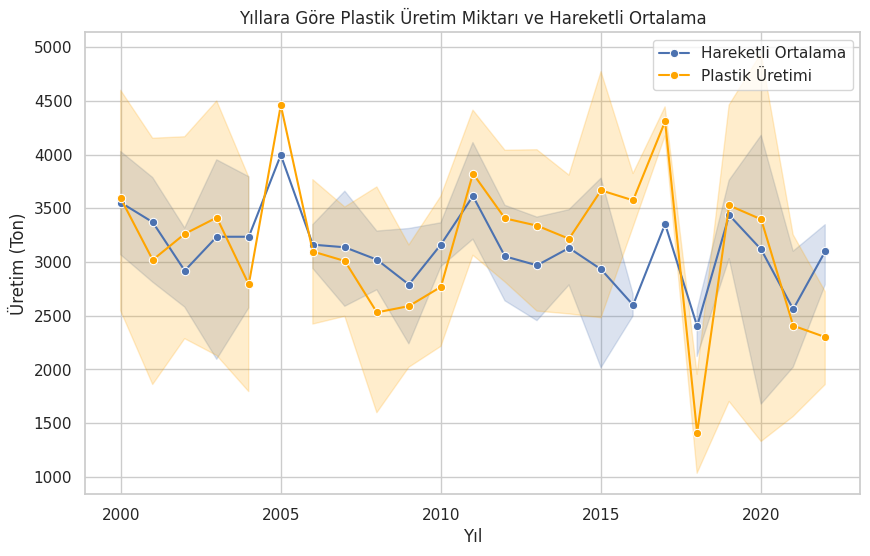

In [ ]:
# Plastik üretimi için hareketli ortalama
df1['moving_average'] = df1['production_ton'].rolling(window=3).mean()
plt.figure(figsize=(10, 6))
sns.lineplot(data=df1, x='year', y='moving_average', marker='o', label="Hareketli Ortalama")
sns.lineplot(data=df1, x='year', y='production_ton', marker='o', color='orange', label="Plastik Üretimi")
plt.title("Yıllara Göre Plastik Üretim Miktarı ve Hareketli Ortalama")
plt.xlabel("Yıl")
plt.ylabel("Üretim (Ton)")
plt.legend()
plt.show()


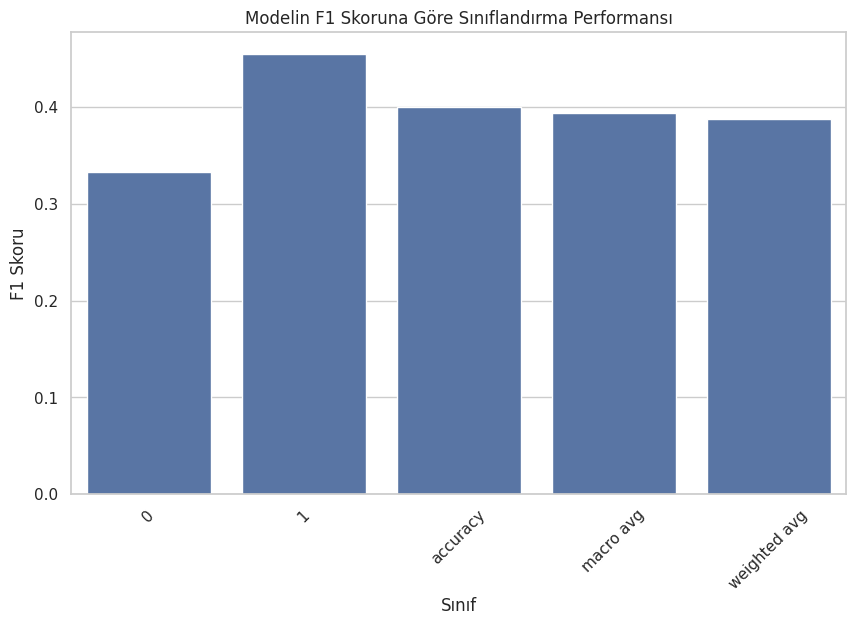

In [ ]:
# Model Doğruluğu ve Sınıflandırma Raporunu Görselleştirme
from sklearn.metrics import classification_report
import pandas as pd

# Örnek veriler: Model doğruluğu ve sınıflandırma sonuçları
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(10, 6))
sns.barplot(x=report_df.index, y=report_df['f1-score'])
plt.title("Modelin F1 Skoruna Göre Sınıflandırma Performansı")
plt.xlabel("Sınıf")
plt.ylabel("F1 Skoru")
plt.xticks(rotation=45)
plt.show()


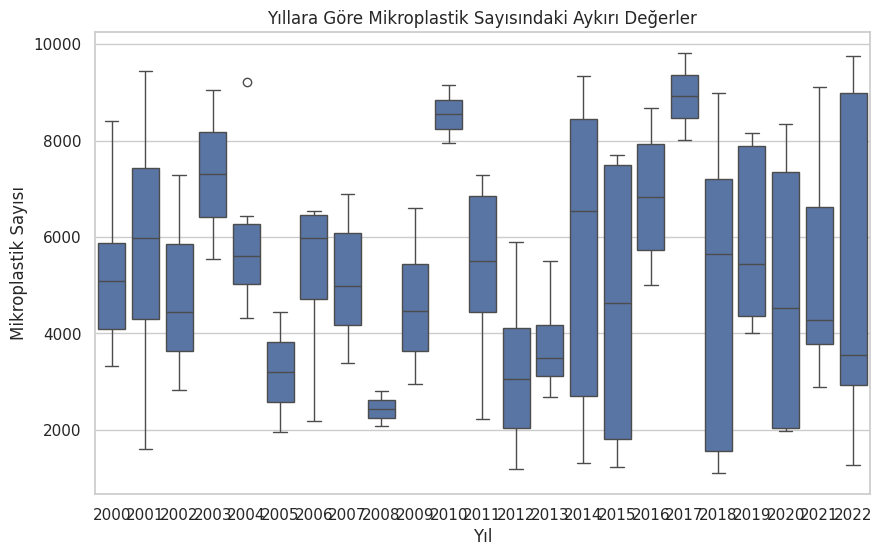

In [ ]:
# Mikroplastik sayısı için aykırı değer analizi
plt.figure(figsize=(10, 6))
sns.boxplot(data=df2, x='year', y='microplastic_count')
plt.title("Yıllara Göre Mikroplastik Sayısındaki Aykırı Değerler")
plt.xlabel("Yıl")
plt.ylabel("Mikroplastik Sayısı")
plt.show()


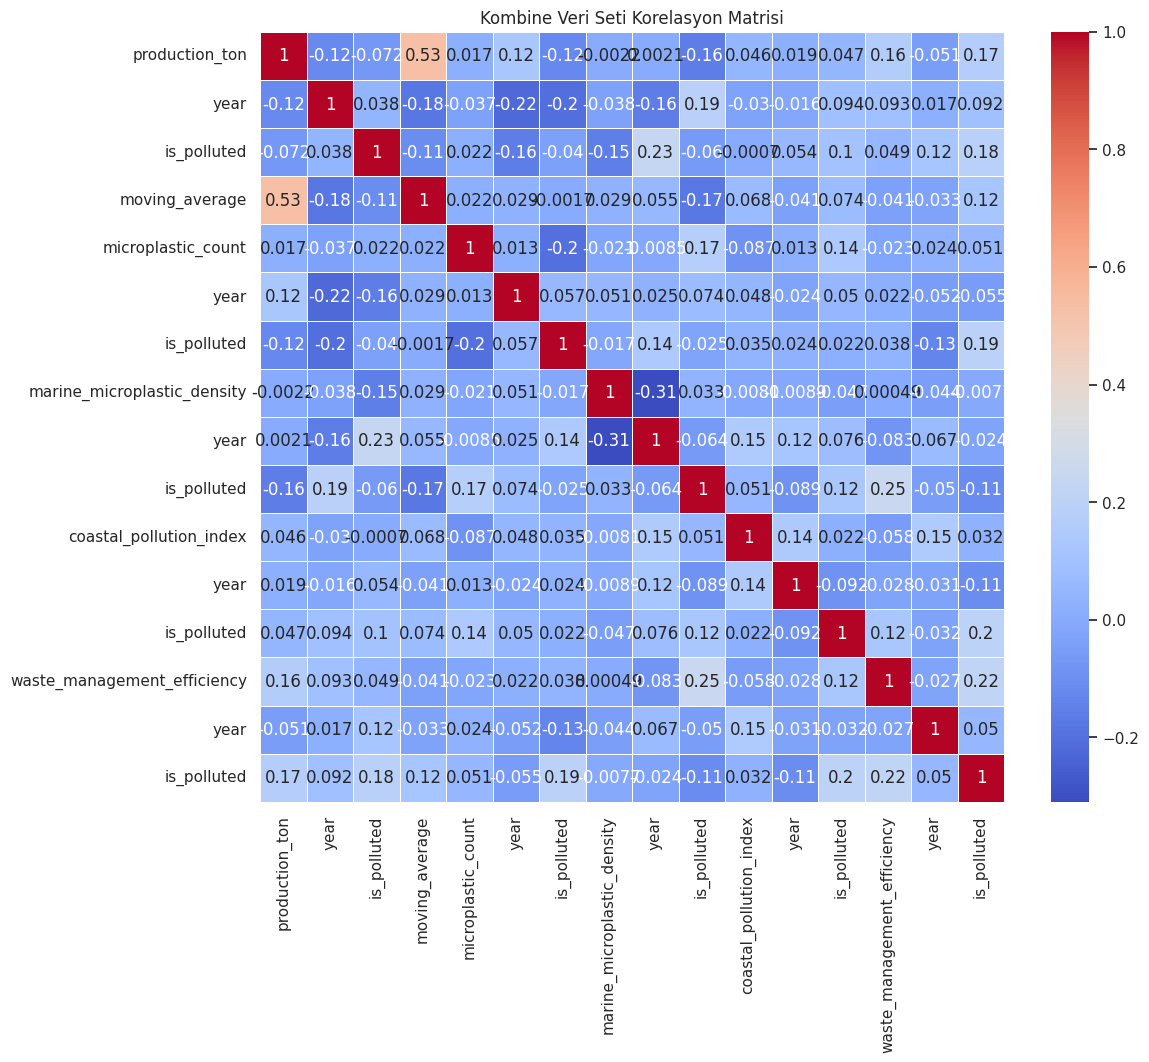

In [ ]:
# Birden fazla veri seti için korelasyon analizi
combined_df = pd.concat([df1, df2, df3, df4, df5], axis=1)  # Veri setlerini birleştirme
plt.figure(figsize=(12, 10))
sns.heatmap(combined_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Kombine Veri Seti Korelasyon Matrisi")
plt.show()


In [ ]:
adv_sci = gpd.read_file('/content/ADVENTURE_MICRO_FROM_SCIENTIST.csv',)
geomar = gpd.read_file('/content/GEOMARINE_MICRO.csv')
sea_micro = gpd.read_file('/content/Marine_Microplastics_WGS84_7659999644124488856.csv')

In [ ]:
def get_geom(df, adn):
    '''get a geometry variable'''
    df[['Latitude', 'Longitude']] = df[['Latitude', 'Longitude']].astype(dtype=float)
    if adn in df.columns:
        df[adn] = df[adn].astype(dtype=float)
    else:
        print(f"Warning: '{adn}' column not found in DataFrame.")
    df['Geometry'] = pd.Series([(df.loc[i, 'Latitude'], df.loc[i, 'Longitude']) for i in range(len(df['Latitude']))])


In [ ]:
def to_datetime(df, date_col='Date', frmt='%Y-%m-%d'):
    '''add_date col as datetime'''
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
        df['year'] = df[date_col].dt.year
    else:
        print(f"Warning: '{date_col}' column not found in DataFrame.")


In [ ]:
# Geometriyi al
get_geom(adv_sci, 'Total_Pieces_L')
get_geom(geomar, 'MP_conc__particles_cubic_metre_')
get_geom(sea_micro, 'Total_Pieces_KM2')  # Burada doğru isimle değiştir

# Tarihleri datetime olarak ayarla
to_datetime(adv_sci)
to_datetime(geomar)
to_datetime(sea_micro)  # Yine burada da doğru isimle değiştir


In [ ]:
#set style for visualization
plt.style.use('seaborn-white')

In [ ]:
import matplotlib.pyplot as plt

def plot_hist(arr, label, n_bins=30):
    plt.figure(figsize=(10, 6))
    plt.hist(arr, bins=n_bins, alpha=0.7, color='blue', edgecolor='black')
    plt.title(f'Histogram of {label}')
    plt.xlabel(label)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()


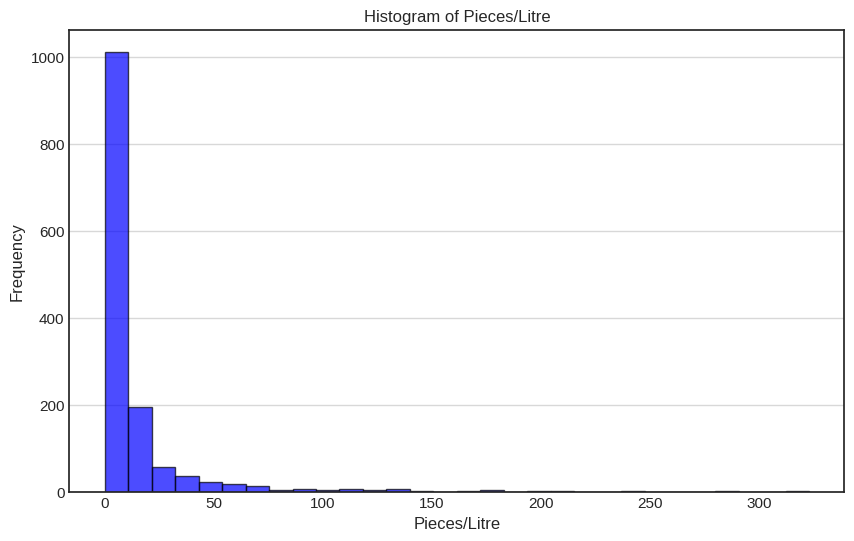

In [ ]:
# Histogramı çiz
plot_hist(arr=adv_sci['Total_Pieces_L'],
          label='Pieces/Litre',
          n_bins=30)


In [ ]:
#find loc with most dense

max_plas = adv_sci['Total_Pieces_L'].max()
idx= adv_sci[adv_sci['Total_Pieces_L']==max_plas].index
date1=str(adv_sci.loc[idx,'Date'].values).split('T')[0].split('[')[1]
loc1= adv_sci.iloc[idx][['Latitude','Longitude']].values

print('Maximum plastic found per Litre is {} on date {} at {}'.format(max_plas,date1,loc1))

Maximum plastic found per Litre is 323.0 on date '2015-11-12 at [[ 34.2     -77.26667]]


In [ ]:
import folium

# Başlangıç konumu
start_loc = (np.mean(adv_sci['Latitude']), np.mean(adv_sci['Longitude']))

# Harita oluşturma (OpenStreetMap ile)
m_1 = folium.Map(location=start_loc,
                  tiles='OpenStreetMap',
                  zoom_start=2,
                  min_zoom=1.5)

# Harita döşemesi için atıf ekleme
folium.TileLayer(
    tiles='OpenStreetMap',
    attr='&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
).add_to(m_1)

# Isı haritası ekleme
HeatMap(data=adv_sci[['Latitude', 'Longitude', 'Total_Pieces_L']].values,
         radius=10,
         blur=5).add_to(m_1)

# En yüksek yoğunluğa sahip alanı ekleme
loc1 = adv_sci[['Latitude', 'Longitude']].values
folium.CircleMarker(location=(loc1[0][0], loc1[0][1]),
                    tooltip="<b>max plastic density</b>",
                    color='black',
                    radius=15).add_to(m_1)

print('Study area Heatmap (Adventure Scientist)')
m_1



Study area Heatmap (Adventure Scientist)


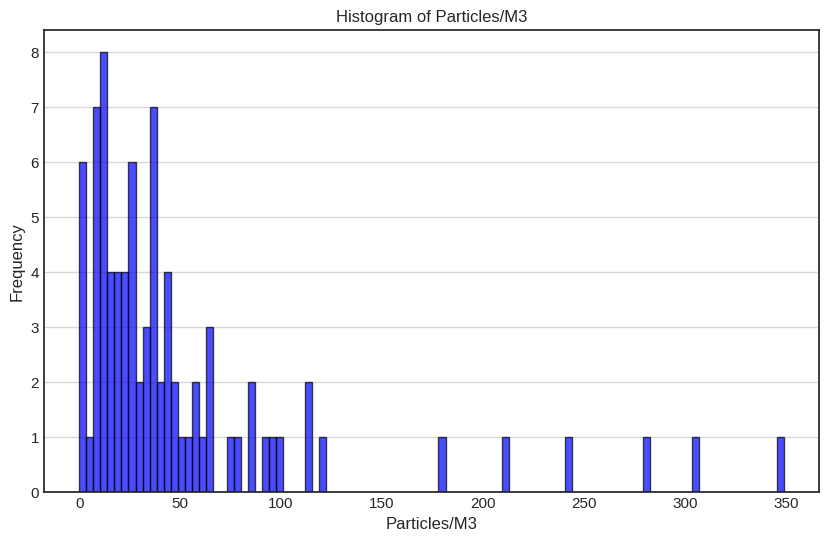

In [ ]:
#distribution of data
plot_hist(arr=geomar['MP_conc__particles_cubic_metre_'],
         label='Particles/M3',
         n_bins=100)

In [ ]:
# geomar['Datto_listd.to_datetime(geomar['Date'],errors='coerce')

mas_plas = geomar['MP_conc__particles_cubic_metre_'].max()
loc2=geomar[geomar['MP_conc__particles_cubic_metre_']==mas_plas][['Latitude','Longitude']].values

print('Maximum micro plastic concentration found per Cubic Meter is {} at {}'.format(max_plas,
                                                                     loc2))

Maximum micro plastic concentration found per Cubic Meter is 323.0 at [[ 21.50771174 119.5476918 ]]


In [ ]:
import folium
from folium.plugins import HeatMap

# Başlangıç konumu
start_loc = (np.mean(adv_sci['Latitude']), np.mean(adv_sci['Longitude']))

# Harita oluşturma
m_3 = folium.Map(location=start_loc,
                  zoom_start=2,
                  min_zoom=1.5)

# OpenStreetMap döşemesini ekleme ve atıf sağlama
folium.TileLayer(
    tiles='OpenStreetMap',
    attr='&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
).add_to(m_3)

# Isı haritası ekleme
HeatMap(data=adv_sci[['Latitude', 'Longitude', 'Total_Pieces_L']].values,
         radius=10,
         blur=5).add_to(m_3)

# En yüksek yoğunluğa sahip alanı ekleme
loc1 = adv_sci[['Latitude', 'Longitude']].values
folium.CircleMarker(location=(loc1[0][0], loc1[0][1]),
                    tooltip="<b>max plastic density</b>",
                    color='black',
                    radius=15).add_to(m_3)

print('Study area Heatmap (Adventure Scientist)')
m_3


Study area Heatmap (Adventure Scientist)


In [ ]:
m_4 = folium.Map(location=start_loc,
                  tiles='OpenStreetMap',  # Doğru yazım
                  zoom_start=2,
                  min_zoom=1.5)
import folium
from folium.plugins import HeatMap

# Başlangıç konumu
start_loc = (np.mean(adv_sci['Latitude']), np.mean(adv_sci['Longitude']))

# Harita oluşturma
m_4 = folium.Map(location=start_loc,
                  zoom_start=2,
                  min_zoom=1.5)

# OpenStreetMap döşemesini ekleme ve atıf sağlama
folium.TileLayer(
    tiles='OpenStreetMap',
    attr='&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
).add_to(m_4)

# Isı haritası ekleme
HeatMap(data=adv_sci[['Latitude', 'Longitude', 'Total_Pieces_L']].values,
         radius=10,
         blur=5).add_to(m_4)

# En yüksek yoğunluğa sahip alanı ekleme
loc1 = adv_sci[['Latitude', 'Longitude']].values
folium.CircleMarker(location=(loc1[0][0], loc1[0][1]),
                    tooltip="<b>max plastic density</b>",
                    color='black',
                    radius=15).add_to(m_4)

print('Study area Heatmap (Adventure Scientist)')
m_4


Study area Heatmap (Adventure Scientist)


In [ ]:
import folium
from folium.plugins import HeatMap

# Başlangıç konumu
start_loc = (np.mean(adv_sci['Latitude']), np.mean(adv_sci['Longitude']))

# Harita oluşturma
m_5 = folium.Map(location=start_loc,
                  tiles='OpenStreetMap',  # Doğru yazım
                  zoom_start=2,
                  min_zoom=1.5)

# Isı haritası ekleme
HeatMap(data=adv_sci[['Latitude', 'Longitude', 'Total_Pieces_L']].values,
         radius=10,
         blur=5).add_to(m_5)

# En yüksek yoğunluğa sahip alanı ekleme
loc1 = adv_sci[['Latitude', 'Longitude']].values
folium.CircleMarker(location=(loc1[0][0], loc1[0][1]),
                    tooltip="<b>max plastic density</b>",
                    color='black',
                    radius=15).add_to(m_5)

print('Study area Heatmap (Adventure Scientist)')
m_5


Study area Heatmap (Adventure Scientist)


In [ ]:
import folium
import numpy as np
import pandas as pd
from folium.plugins import HeatMap

# Örnek veri oluşturma
adv_sci = pd.DataFrame({
    'Latitude': [34.0522, 36.7783],
    'Longitude': [-118.2437, -119.4179],
    'Total_Pieces_L': [10, 20]
})

# Başlangıç konumu
start_loc = (np.mean(adv_sci['Latitude']), np.mean(adv_sci['Longitude']))

# Harita oluşturma (OpenStreetMap kullanma)
m_6 = folium.Map(location=start_loc,
                  tiles='OpenStreetMap',  # Bu döşeme varsayılan atıf içerir
                  zoom_start=2,
                  min_zoom=1.5)

# Isı haritası ekleme
HeatMap(data=adv_sci[['Latitude', 'Longitude', 'Total_Pieces_L']].values,
         radius=10,
         blur=5).add_to(m_6)

# En yüksek yoğunluğa sahip alanı ekleme
loc1 = adv_sci[['Latitude', 'Longitude']].values
folium.CircleMarker(location=(loc1[0][0], loc1[0][1]),
                    tooltip="<b>max plastic density</b>",
                    color='black',
                    radius=15).add_to(m_6)

# Haritayı gösterme
print('Study area Heatmap (Adventure Scientist)')
m_6.save('heatmap.html')  # Haritayı bir HTML dosyasına kaydedin
m_6  # Jupyter Notebook'ta görüntüle


Study area Heatmap (Adventure Scientist)


In [ ]:
m_6 = folium.Map(location=start_loc,
                  tiles='YOUR_CUSTOM_TILE_URL',  # Kendi döşemeniz için URL girin
                  attr='&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
                  zoom_start=2,
                  min_zoom=1.5)

In [ ]:
!pip install confluent-kafka


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 13.3 MB/s eta 0:00:00


Genel Etki: 54.8148148148149


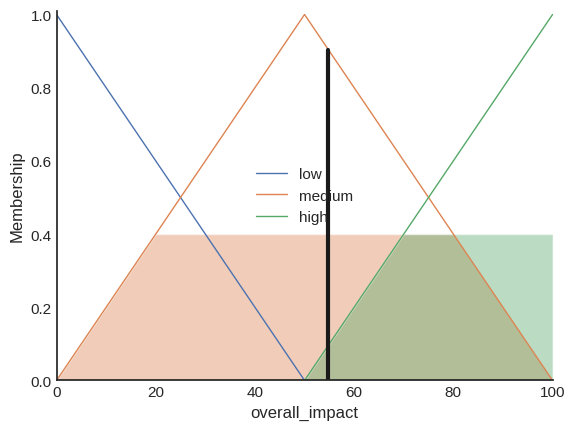

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# Girdi değişkenleri
health_impact = ctrl.Antecedent(np.arange(0, 101, 1), 'health_impact')
gender_equality_impact = ctrl.Antecedent(np.arange(0, 101, 1), 'gender_equality_impact')

# Çıktı değişkeni
overall_impact = ctrl.Consequent(np.arange(0, 101, 1), 'overall_impact')

# Üyelik fonksiyonları
health_impact['low'] = fuzz.trimf(health_impact.universe, [0, 0, 50])
health_impact['medium'] = fuzz.trimf(health_impact.universe, [0, 50, 100])
health_impact['high'] = fuzz.trimf(health_impact.universe, [50, 100, 100])

gender_equality_impact['low'] = fuzz.trimf(gender_equality_impact.universe, [0, 0, 50])
gender_equality_impact['medium'] = fuzz.trimf(gender_equality_impact.universe, [0, 50, 100])
gender_equality_impact['high'] = fuzz.trimf(gender_equality_impact.universe, [50, 100, 100])

overall_impact['low'] = fuzz.trimf(overall_impact.universe, [0, 0, 50])
overall_impact['medium'] = fuzz.trimf(overall_impact.universe, [0, 50, 100])
overall_impact['high'] = fuzz.trimf(overall_impact.universe, [50, 100, 100])

# Kurallar
rule1 = ctrl.Rule(health_impact['low'] & gender_equality_impact['low'], overall_impact['low'])
rule2 = ctrl.Rule(health_impact['medium'] & gender_equality_impact['medium'], overall_impact['medium'])
rule3 = ctrl.Rule(health_impact['high'] & gender_equality_impact['high'], overall_impact['high'])

# Kontrol sistemi
overall_impact_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
overall_impact_simulation = ctrl.ControlSystemSimulation(overall_impact_ctrl)

# Girdi değerleri
overall_impact_simulation.input['health_impact'] = 80  # Örnek sağlık etkisi
overall_impact_simulation.input['gender_equality_impact'] = 70  # Örnek cinsiyet eşitliği etkisi

# Simülasyonu çalıştır
overall_impact_simulation.compute()

# Sonuç
print(f"Genel Etki: {overall_impact_simulation.output['overall_impact']}")
overall_impact.view(sim=overall_impact_simulation)
plt.show()


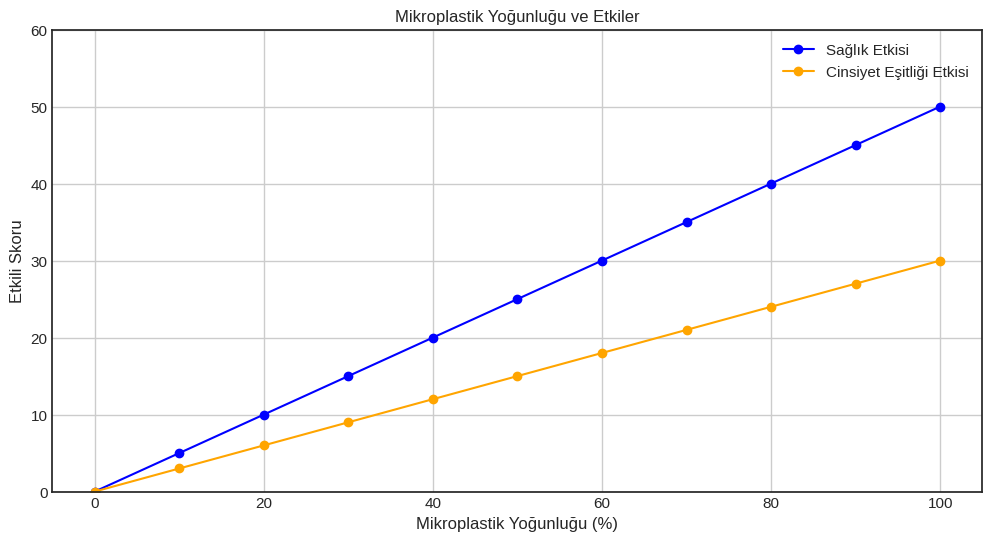

In [ ]:
# Örnek mikroplastik yoğunlukları (örnek veriler)
concentrations = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

# Sağlık etkisi ve cinsiyet eşitliği etkisini hesaplama (örnek hesaplamalar)
health_impacts = np.array([i * 0.5 for i in concentrations])  # Örnek sağlık etkisi hesaplaması
gender_impacts = np.array([i * 0.3 for i in concentrations])   # Örnek cinsiyet eşitliği etkisi hesaplaması

# Grafiği oluşturma
plt.figure(figsize=(12, 6))

# Sağlık etkisi grafiği
plt.plot(concentrations, health_impacts, label='Sağlık Etkisi', color='blue', marker='o')
plt.plot(concentrations, gender_impacts, label='Cinsiyet Eşitliği Etkisi', color='orange', marker='o')

# Başlık ve etiketler
plt.title('Mikroplastik Yoğunluğu ve Etkiler')
plt.xlabel('Mikroplastik Yoğunluğu (%)')
plt.ylabel('Etkili Skoru')
plt.legend()
plt.grid()

# Y ekseninin sınırlarını ayarlama (isteğe bağlı)
plt.ylim(0, max(health_impacts.max(), gender_impacts.max()) + 10)

# Grafiği gösterme
plt.show()


In [ ]:
# Sağlık etkisi ve cinsiyet eşitliği etkisini hesaplama
health_impacts = np.array([i * 0.5 for i in concentrations])  # NumPy dizisi
gender_impacts = np.array([i * 0.3 for i in concentrations])   # NumPy dizisi

# Sonuçları yazdırma
print("Sağlık Etkisi Skorları:", health_impacts)
print("Cinsiyet Eşitliği Etkisi Skorları:", gender_impacts)


Sağlık Etkisi Skorları: [ 0.  5. 10. 15. 20. 25. 30. 35. 40. 45. 50.]
Cinsiyet Eşitliği Etkisi Skorları: [ 0.  3.  6.  9. 12. 15. 18. 21. 24. 27. 30.]


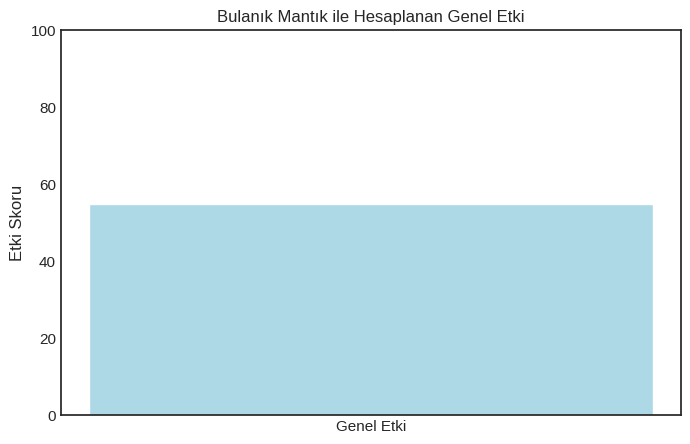

In [ ]:
# Genel etkiyi görselleştirme
plt.figure(figsize=(8, 5))
plt.bar(['Genel Etki'], [overall_impact_simulation.output['overall_impact']], color='lightblue')
plt.ylim(0, 100)
plt.title('Bulanık Mantık ile Hesaplanan Genel Etki')
plt.ylabel('Etki Skoru')
plt.show()


In [ ]:
# Sağlık ve cinsiyet eşitliği etki skorları
health_scores = np.array([0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50])
gender_scores = np.array([0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30])

# Ağırlıklı ortalama hesaplama
overall_scores = (health_scores * 0.6) + (gender_scores * 0.4)  # Ağırlıklar isteğe bağlı olarak değiştirilebilir

print("Genel Etki Skorları:", overall_scores)


Genel Etki Skorları: [ 0.   4.2  8.4 12.6 16.8 21.  25.2 29.4 33.6 37.8 42. ]


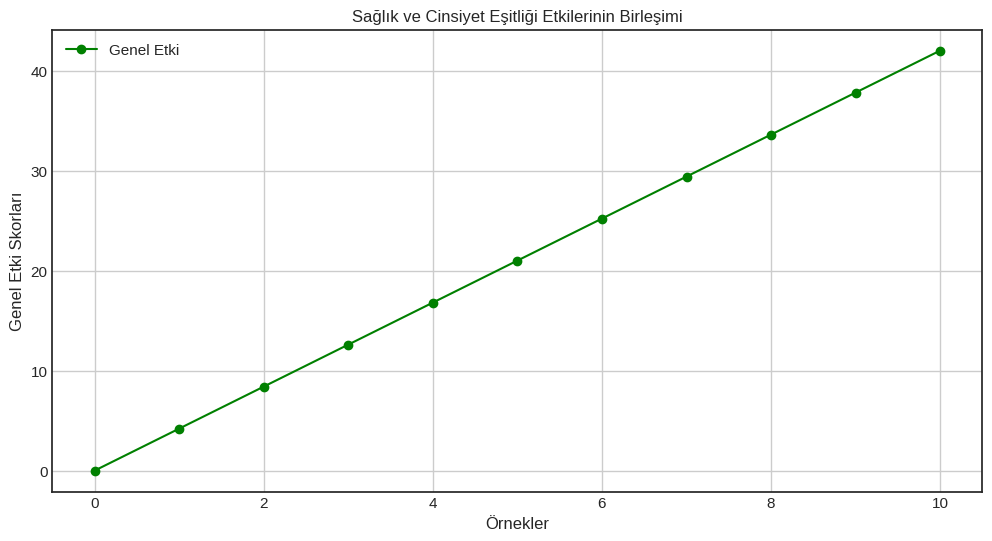

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(overall_scores, label='Genel Etki', color='green', marker='o')
plt.xlabel('Örnekler')
plt.ylabel('Genel Etki Skorları')
plt.title('Sağlık ve Cinsiyet Eşitliği Etkilerinin Birleşimi')
plt.legend()
plt.grid()
plt.show()
